In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('../data/advertising.csv', index_col=0)

print("Data loaded ✅")
print("Shape:", df.shape)
df.head()

Data loaded ✅
Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

print("=== Normal Linear Regression Results ===")
print()
for feature, coef in zip(X.columns, model.coef_):
    print(f'{feature}: {coef:.4f}')

print()
print(f'R2 Score: {r2_score(y, model.predict(X)):.4f}')

=== Normal Linear Regression Results ===

TV: 0.0458
Radio: 0.1885
Newspaper: -0.0010

R2 Score: 0.8972


In [4]:
print("=== THE CORRELATION TRAP ===")
print()
print("Newspaper coefficient is nearly 0")
print("So is Newspaper spending truly wasted money?")
print()
print("Correlation of Newspaper with Radio:")
print(round(df['Newspaper'].corr(df['Radio']), 4))
print()
print("Newspaper and Radio are often spent together.")
print("This confuses the model.")

=== THE CORRELATION TRAP ===

Newspaper coefficient is nearly 0
So is Newspaper spending truly wasted money?

Correlation of Newspaper with Radio:
0.3541

Newspaper and Radio are often spent together.
This confuses the model.


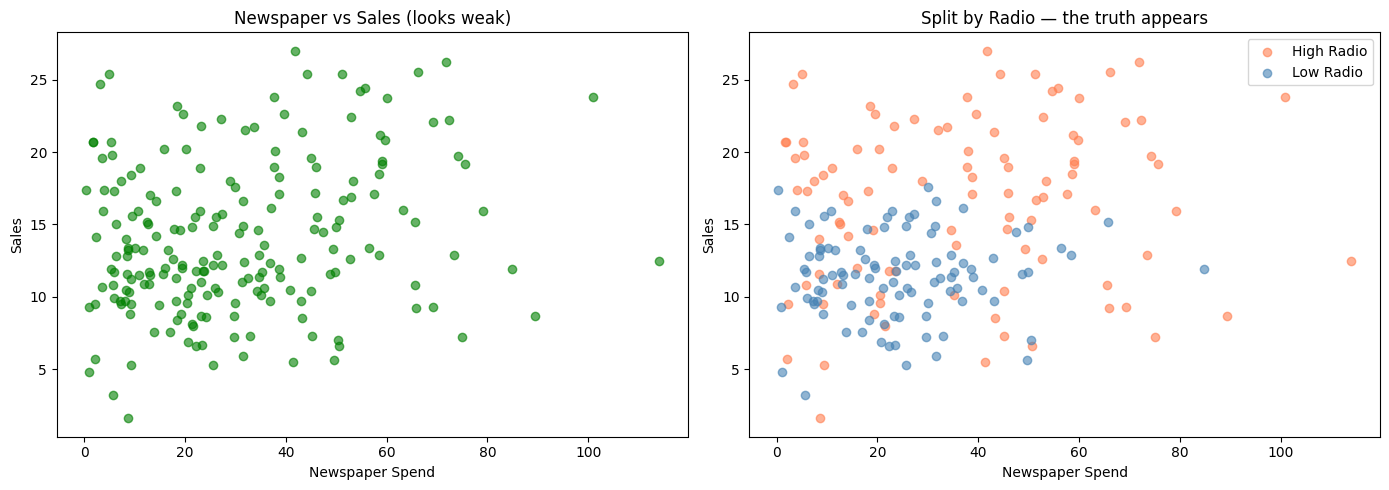

Chart saved ✅


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Newspaper'], df['Sales'], alpha=0.6, color='green')
axes[0].set_xlabel('Newspaper Spend')
axes[0].set_ylabel('Sales')
axes[0].set_title('Newspaper vs Sales (looks weak)')

high_radio = df[df['Radio'] > df['Radio'].median()]
low_radio  = df[df['Radio'] <= df['Radio'].median()]

axes[1].scatter(high_radio['Newspaper'], high_radio['Sales'],
               alpha=0.6, color='coral', label='High Radio')
axes[1].scatter(low_radio['Newspaper'], low_radio['Sales'],
               alpha=0.6, color='steelblue', label='Low Radio')
axes[1].set_xlabel('Newspaper Spend')
axes[1].set_ylabel('Sales')
axes[1].set_title('Split by Radio — the truth appears')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/correlation_trap.png')
plt.show()
print("Chart saved ✅")